In [7]:
import os
import re

rootpath_raw = "./data/raw"

# list a dir content
listing = None
try:
    listing = os.listdir(rootpath_raw)
except Exception as e:
    print(f"Error listing directory: {e}")

allvalues_raw = []
v1v2pair_raw = set()
for fname in listing:
    # check if fname it  a dir
    if os.path.isdir(rootpath_raw + "/" + fname):
        #print(f"{fname} is a directory")
        #use a regular exprtession to split v11v11 into v11 and v11
        match = re.match(r"v(\d+)v(\d+)", fname)
        if match:            
            v1dir = match.group(1)
            v2dir = match.group(2)
            v1v2pair_raw.add((int(v1dir), int(v2dir)))
            #print(f"v1: {v1dir}, v2: {v2dir}")
            for datafile in os.listdir(rootpath_raw + "/" + fname):
                #print(f"  {datafile}")
                viroval = datafile.split(".")[0]
                #print(f"    viroval: {viroval}")
                # re to split v11v11j01j01 into v11, v11, j01, j01
                match2 = re.match(r"v(\d+)v(\d+)j(\d+)j(\d+)", viroval)
                if match2:
                    v1 = match2.group(1)
                    v2 = match2.group(2)
                    j1 = match2.group(3)
                    j2 = match2.group(4)
                    if v1 != v1dir or v2 != v2dir:
                        print(f"ERROR: {datafile} does not match the pattern v{v1dir}v{v2dir}j{j1}j{j2}")
                        exit(1)
                    fp = os.path.join(rootpath_raw, fname, datafile)
                    infileval = []
                    for line in open(fp):
                        line = line.strip()
                        sline = line.split()
                        if len(sline) == 2:
                            e = float(sline[0])
                            c = float(sline[1])
                            infileval.append((e, c))
                        else:
                            print(f"Warning: {datafile} has a line that does not have 2 values: {line}")
                            continue
                    allvalues_raw.append((int(v1), 
                                      int(v2), 
                                      int(j1), 
                                      int(j2), 
                                      infileval))
                    #print(f"    v1: {v1}, v2: {v2}, j1: {j1}, j2: {j2}")
        else:
            print(f"Warning: {fname} does not match the pattern v{v1dir}v{v2dir}")
    else:
        print(f"Warning: {fname} is a file") 


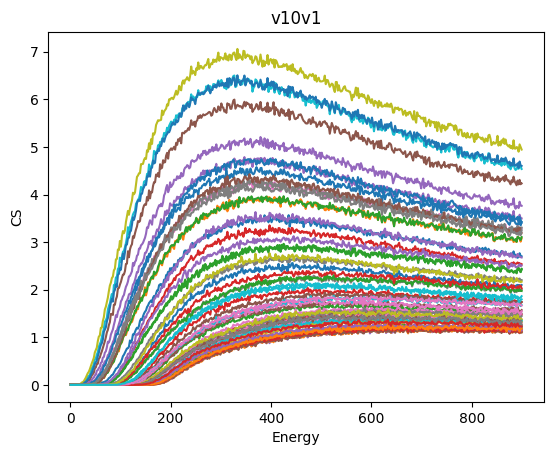

In [10]:
import matplotlib.pyplot as plt
# to plot all
#for v1t, v2t in v1v2pair_raw:
#    plt.clf()
# a selection of v1t and v2t
v1t = 10
v2t = 1

if (v1t, v2t) in v1v2pair_raw:
    for v1, v2, j1, j2, infileval in allvalues_raw:
        if v1 == v1t and v2 == v2t:
            e = [x[0] for x in infileval]
            c = [x[1] for x in infileval]
            plt.plot(e, c, label=f"v{v1}v{v2}j{j1}j{j2}")
    plt.xlabel("Energy")
    plt.ylabel("CS")
    plt.title(f"v{v1t}v{v2t}")
    #plt.legend()
    plt.show()

In [11]:
rootpath_fitted = "./data/fitted"
LINEDIM = 20
# list a dir content
listing = None
try:
    listing = os.listdir(rootpath_fitted)
except Exception as e:
    print(f"Error listing directory: {e}")

allvalues_fitted = []
v1v2pair_fitted = set()
for fname in listing:
    # check if fname it  a dir
    if os.path.isdir(rootpath_fitted + "/" + fname):
        #print(f"{fname} is a directory")
        #use a regular exprtession to split v11v11 into v11 and v11
        match = re.match(r"v(\d+)v(\d+)", fname)
        if match:            
            v1dir = match.group(1)
            v2dir = match.group(2)
            v1v2pair_fitted.add((int(v1dir), int(v2dir)))
            #print(f"v1: {v1dir}, v2: {v2dir}")
            for datafile in os.listdir(rootpath_fitted + "/" + fname):
                #print(f"  {datafile}")
                viroval = datafile.split(".")[0]
                #print(f"    viroval: {viroval}")
                # re to split v11v11j01j01 into v11, v11, j01, j01
                match2 = re.match(r"v(\d+)v(\d+)j(\d+)j(\d+)", viroval)
                if match2:
                    v1 = match2.group(1)
                    v2 = match2.group(2)
                    j1 = match2.group(3)
                    j2 = match2.group(4)
                    if v1 != v1dir or v2 != v2dir:
                        print(f"ERROR: {datafile} does not match the pattern v{v1dir}v{v2dir}j{j1}j{j2}")
                        exit(1)
                    fp = os.path.join(rootpath_fitted, fname, datafile)
                    infileval = []
                    line = open(fp).readlines()
                    if len(line) != 1:
                        print(f"Warning: {datafile} has more than 1 line, only the first line will be read")
                    line = line[0].strip()
                    slines = line.split()
                    if len(slines) != LINEDIM:
                        print(f"Warning: {datafile} does not have {2 * LINEDIM} values, it has {len(slines)} values"    )
                    else:
                        a1 = int(slines[0])
                        assert a1 == int(v1)
                        a2 = int(slines[1])
                        assert a2 == int(v2)
                        a3 = int(slines[2])
                        assert a3 == int(j1)
                        a4 = int(slines[3])
                        assert a4 == int(j2)
                        coeffs = []
                        for v in slines[4:]:
                            coeffs.append(float(v.replace('D', 'E').replace('d', 'e')))
                    
                    allvalues_fitted.append((int(v1), 
                                      int(v2), 
                                      int(j1), 
                                      int(j2), 
                                      coeffs))
                    #print(f"    v1: {v1}, v2: {v2
                        
        else:
            print(f"Warning: {fname} does not match the pattern v{v1dir}v{v2dir}")
    else:
        print(f"Warning: {fname} is a file") 



In [12]:
assert v1v2pair_raw == v1v2pair_fitted, f"v1v2pair_raw: {v1v2pair_raw}, v1v2pair_fitted: {v1v2pair_fitted}"

In [ ]:
def legpol(xx, nleg):
    """
    Calculates Legendre polynomials at point xx.
    nleg = number of coefficients (exponents from 0 to nleg-1).
    """
    pol = [0.0] * nleg
    
    if nleg > 0:
        pol[0] = 1.0  # Equivalent to p(0)=1.d0 [cite: 4]
    if nleg > 1:
        pol[1] = xx   # Equivalent to p(1)=xx [cite: 4]
        
    for i in range(2, nleg):
        # Recurrence relation for Legendre polynomials [cite: 5]
        pol[i] = ((2 * i - 1) * xx * pol[i-1] - (i - 1) * pol[i-2]) / i
        
    return pol


def legder(xx, nleg):
    """
    Calculates the derivatives of Legendre polynomials at point xx.
    nleg = number of coefficients (exponents from 0 to nleg-1).
    """
    p = [0.0] * nleg
    der = [0.0] * nleg
    
    if nleg > 0:
        p[0] = 1.0    # Equivalent to p(0)=1.d0 [cite: 5]
        der[0] = 0.0  # Equivalent to d(0)=0.d0 [cite: 5]
    if nleg > 1:
        p[1] = xx     # Equivalent to p(1)=xx [cite: 5]
        der[1] = 1.0  # Equivalent to d(1)=1.d0 [cite: 6]
        
    for i in range(2, nleg):
        # Polynomial recurrence relation [cite: 6]
        p[i] = ((2 * i - 1) * xx * p[i-1] - (i - 1) * p[i-2]) / i
        
        # Derivative recurrence relation [cite: 6]
        der[i] = ((2 * i - 1) * (p[i-1] + xx * der[i-1]) - (i - 1) * der[i-2]) / i
        
    return der


def generate_fitted_curve(e0, coeffs, e1=0.0, e2=900.0):
    """
    Generates the excitation function and derivative over an energy grid.
    Translates the Fortran loops and uses the legpol/legder functions.
    """
    nleg = len(coeffs)
    delta = e2 - e1
    
    # Calculate starting and ending indices based on e0 
    ie0 = int(round(e0 * 1000.0))
    ie1 = int(round(e0 * 10.0)) + 1
    ie2 = ie1 * 100 - 1
    
    energies = []
    csfits = []
    csders = []
    
    # --- FIRST LOOP: Fine energy grid (step of 0.001) --- 
    # Fortran: do ie=ie0,ie2 
    for ie in range(ie0, ie2 + 1):
        e = ie * 0.001  # 
        
        # Calculate normalized variable xx 
        xx = (2.0 * e - e2 - e1) / delta  # 
        
        # Get polynomials and derivatives
        pol = legpol(xx, nleg)
        der = legder(xx, nleg)
        
        # Calculate fit and derivative 
        csfit = sum(c * p for c, p in zip(coeffs, pol))
        csder = sum(c * d for c, d in zip(coeffs, der))
        
        # Scale the derivative [cite: 3]
        csder = csder * 2.0 / delta  # [cite: 3]
        
        energies.append(e)
        csfits.append(csfit)
        csders.append(csder)

    # --- SECOND LOOP: Coarse energy grid (step of 0.1) --- [cite: 3]
    # Fortran: do ie=ie1,9000 [cite: 3]
    for ie in range(ie1, 9000 + 1):
        e = ie * 0.1  # [cite: 3]
        
        # Calculate normalized variable xx [cite: 3]
        xx = (2.0 * e - e2 - e1) / delta  # [cite: 3]
        
        # Get polynomials and derivatives
        pol = legpol(xx, nleg)
        der = legder(xx, nleg)
        
        # Calculate fit and derivative [cite: 3, 4]
        csfit = sum(c * p for c, p in zip(coeffs, pol))
        csder = sum(c * d for c, d in zip(coeffs, der))
        
        # Scale the derivative [cite: 4]
        csder = csder * 2.0 / delta  # [cite: 4]
        
        energies.append(e)
        csfits.append(csfit)
        csders.append(csder)

    return energies, csfits, csders

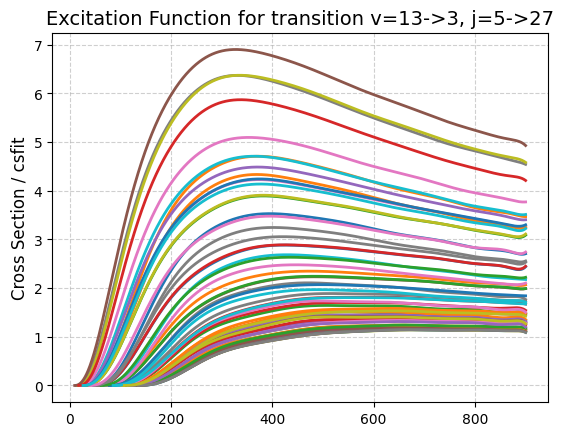

In [18]:
v1t = 10 
v2t = 1

if (v1t, v2t) in v1v2pair_fitted:
    plt.clf()
    for iv1, iv2, ij1, ij2, icoeffs in allvalues_fitted:
        if iv1 == v1t and iv2 == v2t:
            e0 = icoeffs[0]
            coeffs = icoeffs[1:]
            energies, csfits, csders = generate_fitted_curve(e0, coeffs)

            # --- Top Plot: Excitation Function ---
            plt.plot(energies, csfits, linewidth=2, label='Fitted Cross Section')
            #plt.plot(energies, csders, color='red', linewidth=2, label='Derivative')

    plt.ylabel('Cross Section / csfit', fontsize=12)
    plt.title(f'Excitation Function for transition v={iv1}->{iv2}, j={ij1}->{ij2}', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    #plt.legend()

    plt.show()

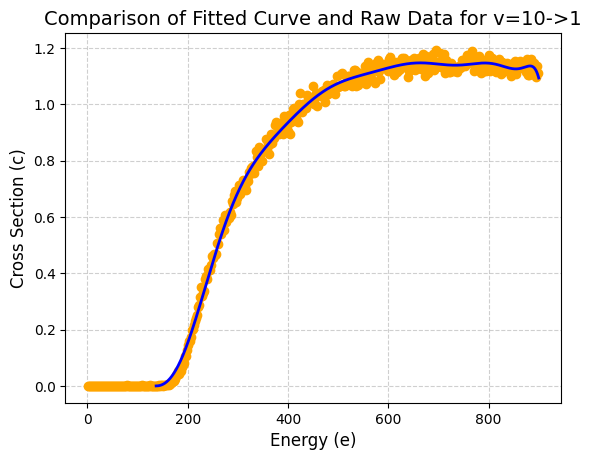

In [21]:
v1 = 10
v2 = 1
j1 = 1
j2 = 1

if (v1, v2) in v1v2pair_fitted and (v1, v2) in v1v2pair_raw:
    plt.clf()
    
    for iv1, iv2, ij1, ij2, infileval in allvalues_raw:
        if iv1 == v1 and iv2 == v2 and ij1 == j1 and ij2 == j2:
            e = [x[0] for x in infileval]
            c = [x[1] for x in infileval]
            plt.plot(e, c, color='orange', marker='o', linestyle='', label='Raw Data')
    for iv1, iv2, ij1, ij2, icoeffs in allvalues_fitted:
        if iv1 == v1 and iv2 == v2 and ij1 == j1 and ij2 == j2:
            e0 = icoeffs[0] 
            coeffs = icoeffs[1:]
            energies, csfits, csders = generate_fitted_curve(e0, coeffs)    
            plt.plot(energies, csfits, color='blue', linewidth=2, label='Fitted Cross Section')
    plt.xlabel("Energy (e)", fontsize=12)
    plt.ylabel("Cross Section (c)", fontsize=12)
    plt.title(f"Comparison of Fitted Curve and Raw Data for v={v1}->{v2}", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)   
    #plt.legend()
    plt.show()